In [129]:
# importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
# Set random seed for reproducibility
np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)

In [130]:
# importing the dataset from kaggle path /kaggle/input/competitions/midad-ml-competition/train_set_.csv
# Load separate train/test files and preprocess both identically
train_path = 'D:/Tamkin AI/DL/LAB/train_set_.csv'
test_path = 'D:/Tamkin AI/DL/LAB/test_set_without lables_.csv'  # adjust if you have a labeled test file
train_raw = pd.read_csv(train_path, sep=';')
test_raw = pd.read_csv(test_path, sep=';')

# checking the first 5 rows of the dataset
train_raw.head()

# checking the shape of the dataset
train_raw.shape

# checking the info of the dataset
train_raw.info()

# checking the statistical summary of the dataset
train_raw.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 5848 non-null   int64  
 1   Name               5848 non-null   str    
 2   Location           5848 non-null   str    
 3   Year               5848 non-null   int64  
 4   Kilometers_Driven  5848 non-null   int64  
 5   Fuel_Type          5848 non-null   str    
 6   Transmission       5848 non-null   str    
 7   Owner_Type         5848 non-null   str    
 8   Mileage            5846 non-null   str    
 9   Engine             5813 non-null   str    
 10  Power              5813 non-null   str    
 11  Seats              5807 non-null   float64
 12  Price              5848 non-null   float64
dtypes: float64(2), int64(3), str(8)
memory usage: 1.0 MB


,ID,Year,Kilometers_Driven,Seats,Price
count,5848.000000,5848.000000,5848.000000,5807.000000,5848.000000
mean,3012.262312,2013.290356,58343.619528,5.282418,8.130381
std,1735.051549,3.271244,38054.637943,0.791450,7.593306
min,0.000000,1998.000000,171.000000,0.000000,0.440000
25%,1512.750000,2011.000000,35000.000000,5.000000,3.450000
50%,3018.500000,2014.000000,54000.000000,5.000000,5.500000
75%,4511.250000,2016.000000,73653.500000,5.000000,9.250000
max,6018.000000,2019.000000,775000.000000,10.000000,40.000000


### preprocessing the dataset

In [131]:
# checking for missing values
print(train_raw.isnull().sum())
print(test_raw.isnull().sum())

ID                    0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               35
Power                35
Seats                41
Price                 0
dtype: int64
ID                   0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               1
Power                1
Seats                1
dtype: int64


In [132]:
# checking for duplicate values
print(train_raw.duplicated().sum())
print(test_raw.duplicated().sum())

0
0


In [133]:
# present the data with filter feuling type = 'Electric'
train_raw[train_raw['Fuel_Type'] == 'Electric']

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
4322,4446,Mahindra E Verito D4,Chennai,2016,50000,Electric,Automatic,First,NaN,72 CC,41 bhp,5.0,13.00
4766,4904,Toyota Prius 2009-2016 Z4,Mumbai,2011,44000,Electric,Automatic,First,NaN,1798 CC,73 bhp,5.0,12.75


In [134]:
test_raw[test_raw['Fuel_Type'] == 'Electric']

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats


we see the 2 missing values in Mileage come with Electric Fuel Tupe

In [135]:
kmkgCNG = 0
kmkgpetrol = 0
kmkgDiesel = 0
kmkgLPG = 0
kmplCNG = 0
kmplPetrol = 0
kmplDiesel = 0
kmplLPG = 0

for i , j in zip(train_raw.Mileage , train_raw.Fuel_Type):
    if str(i).endswith("km/kg") and j == "CNG":
        kmkgCNG+=1
    elif str(i).endswith("km/kg") and j == "Petrol":
        kmkgpetrol+=1
    elif str(i).endswith("km/kg") and j == "Diesel":
        kmkgDiesel+=1
    elif str(i).endswith("km/kg") and j == "LPG":
        kmkgLPG+=1
    elif str(i).endswith("kmpl") and j == "CNG":
        kmplCNG+=1
    elif str(i).endswith("kmpl") and j == "Petrol":
        kmplPetrol+=1
    elif str(i).endswith("kmpl") and j == "Diesel":
        kmplDiesel+=1
    elif str(i).endswith("kmpl") and j == "LPG":
        kmplLPG+=1
print('The number of rows with Km/Kg and CNG : {} '.format(kmkgCNG))
print('The number of rows with Km/Kg and Petrol : {} '.format(kmkgpetrol))
print('The number of rows with Km/Kg and Diesel : {} '.format(kmkgDiesel))
print('The number of rows with Km/Kg and LPG : {} '.format(kmkgLPG))
print('The number of rows with kmpl and CNG : {} '.format(kmplCNG))
print('The number of rows with Km/L and Petrol : {} '.format(kmplPetrol))
print('The number of rows with Km/L and Diesel : {} '.format(kmplDiesel))
print('The number of rows with Km/L and LPG : {} '.format(kmplLPG))
print('The total number of rows : {} '.format(kmkgCNG + kmkgpetrol + kmkgDiesel + kmkgLPG + kmplCNG + kmplPetrol + kmplDiesel + kmplLPG))


The number of rows with Km/Kg and CNG : 56 
The number of rows with Km/Kg and Petrol : 0 
The number of rows with Km/Kg and Diesel : 0 
The number of rows with Km/Kg and LPG : 10 
The number of rows with kmpl and CNG : 0 
The number of rows with Km/L and Petrol : 2721 
The number of rows with Km/L and Diesel : 3059 
The number of rows with Km/L and LPG : 0 
The total number of rows : 5846 


### we have Km/Kg unit with CNG and LPG fuel type and it's so fewer than kmpl
so we should convert Km/Kg to Km/L and after that we use Mileage's column to float

1 kg of CNG occupies roughly 1.4 to 1.5 Liters of volume equivalent under normal dispenser conditions.

so our formula will be:

###     1 KmpL = 1 KmpKg / 1.4 (CNG)

1 Kg of LPG occupies approximately 1.84 Liters of volume under standard automotive fuel tank pressures.

so our formula will be:

###     1 KmpL = 1 KmpKg / 1.84 (LPG)

In [136]:
# 1. Clean the string text and extract raw numerical values
def convert_mileage(row):
    mileage_str = str(row["Mileage"]).strip().lower()

    # Handle missing, null, or invalid entries safely
    if (
        mileage_str == "nan"
        or mileage_str == ""
        or mileage_str == "null"
    ):
        return np.nan

    # Extract numerical part from strings like "26.6 km/kg" or "19.67 kmpl"
    try:
        numeric_value = float(mileage_str.split()[0])
    except (ValueError, IndexError):
        return np.nan

    # 2. Apply fuel-specific logic
    fuel_type = str(row["Fuel_Type"]).strip().upper()

    if fuel_type == "CNG":
        # Convert km/kg to kmpl baseline by dividing by 1.4
        return round(numeric_value / 1.4, 2)
    
    elif fuel_type == "LPG":
        # Convert km/kg to kmpl baseline by dividing by 1.84
        return round(numeric_value / 1.84, 2)

    elif fuel_type in ["PETROL", "DIESEL"]:
        # Petrol and Diesel are already natively in kmpl
        return round(numeric_value, 2)

    return numeric_value

In [137]:
train_raw.isnull().sum()

ID                    0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               35
Power                35
Seats                41
Price                 0
dtype: int64

In [138]:
# checking for missing values in Engine
train_raw[train_raw['Engine'].isnull()]

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
190,194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN,2.95
204,208,Maruti Swift 1.3 VXi,Kolkata,2010,42001,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,2.11
705,733,Maruti Swift 1.3 VXi,Chennai,2006,97800,Petrol,Manual,Third,16.1 kmpl,NaN,NaN,NaN,1.75
721,749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,0.0 kmpl,NaN,NaN,NaN,26.50
1252,1294,Honda City 1.3 DX,Delhi,2009,55005,Petrol,Manual,First,12.8 kmpl,NaN,NaN,NaN,3.20
1284,1327,Maruti Swift 1.3 ZXI,Hyderabad,2015,50295,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,5.80
1339,1385,Honda City 1.5 GXI,Pune,2004,115000,Petrol,Manual,Second,0.0 kmpl,NaN,NaN,NaN,1.50
2008,2074,Maruti Swift 1.3 LXI,Pune,2011,24255,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,3.15
2028,2096,Hyundai Santro LP zipPlus,Coimbatore,2004,52146,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN,1.93
2193,2264,Toyota Etios Liva V,Pune,2012,24500,Petrol,Manual,Second,18.3 kmpl,NaN,NaN,NaN,2.95


back to previous 2 cells there are 35 values missing in Engine and power
but if we see the price it look like the cars didn't have an engine (like missing or broken) so that's why the price is low

# THE FUNCTION OF PREPROCESSING FOR TEST AND TRAIN DATASETS

In [139]:
def preprocess_df(df):
    df = df.copy()
    
    # drop ID if present
    df = df.drop(columns=['ID'], errors='ignore')
    
    # convert mileage using existing convert_mileage function (defined earlier)
    df['Mileage'] = df.apply(convert_mileage, axis=1)
    
    # fill electric fuel mileage missing values with zero
    df.loc[(df['Fuel_Type'] == 'Electric') & (df['Mileage'].isna()), 'Mileage'] = 0
    df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
    df['Mileage'] = df['Mileage'].fillna(df['Mileage'].median())
    
    # clean Engine and Power columns
    df['Engine'] = df['Engine'].astype(str).str.replace(' CC', '', case=False).str.strip()
    df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')
    
    df['Power'] = df['Power'].astype(str).str.replace(' bhp', '', case=False).str.strip()
    df['Power'] = df['Power'].replace('null', np.nan)
    df['Power'] = pd.to_numeric(df['Power'], errors='coerce')
    
    df['Seats'] = pd.to_numeric(df['Seats'], errors='coerce')
    
    # extract brand/model from Name for group-based imputation
    df['Brand'] = df['Name'].apply(lambda x: str(x).split()[0])
    df['Model'] = df['Name'].apply(lambda x: ' '.join(str(x).split()[1:]))
    
    # impute Engine and Power using group medians then global median
    df['Engine'] = df.groupby(['Brand', 'Model'])['Engine'].transform(lambda x: x.fillna(x.median()))
    df['Engine'] = df.groupby(['Brand'])['Engine'].transform(lambda x: x.fillna(x.median()))
    df['Engine'] = df['Engine'].fillna(df['Engine'].median())
    
    df['Power'] = df.groupby(['Model', 'Engine'])['Power'].transform(lambda x: x.fillna(x.median()))
    df['Power'] = df.groupby(['Brand', 'Engine'])['Power'].transform(lambda x: x.fillna(x.median()))
    df['Power'] = df['Power'].fillna(df['Power'].median())
    
    df['Seats'] = df.groupby(['Brand', 'Model'])['Seats'].transform(lambda x: x.fillna(x.median()))
    df['Seats'] = df.groupby(['Brand'])['Seats'].transform(lambda x: x.fillna(x.median()))
    df['Seats'] = df['Seats'].fillna(df['Seats'].median())
    
    df = df.drop(columns=['Name'], errors='ignore')
    return df

train_processed = preprocess_df(train_raw)
test_processed = preprocess_df(test_raw)

In [140]:
# Ensure same feature encoding: fit OHE on train categorical cols and transform test
cat_cols = ['Transmission', 'Fuel_Type', 'Location', 'Owner_Type', 'Brand', 'Model']
num_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

# Initialize OHE directly
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Transform ONLY the categorical columns
encoded_train = ohe.fit_transform(train_processed[cat_cols])
encoded_test = ohe.transform(test_processed[cat_cols])

# Turn the encoded matrix back into a DataFrame with column names
encoded_train_df = pd.DataFrame(encoded_train, columns=ohe.get_feature_names_out(cat_cols), index=train_processed.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(cat_cols), index=test_processed.index)

# Manually stitch it together with continuous numeric columns
train_final = pd.concat([encoded_train_df, train_processed[num_cols + ['Price']]], axis=1)
test_final = pd.concat([encoded_test_df, test_processed[num_cols]], axis=1)

# expose final train/test frames for downstream cells
train_final.shape, test_final.shape

d:\Tamkin AI\DL\LAB\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


((5848, 1860), (171, 1859))

In [141]:
# Use processed train/test frames created earlier
# train_final contains the encoded categorical features + numeric columns + 'Price'
X_train_df = train_final.drop('Price', axis=1)
y_train = train_final['Price']
# test_final may or may not contain 'Price' depending on the competition file
if 'Price' in test_final.columns:
    X_test_df = test_final.drop('Price', axis=1)
    y_test = test_final['Price']
else:
    X_test_df = test_final.copy()
    y_test = None
X_train_df.shape, (y_train.shape if y_train is not None else None), X_test_df.shape

((5848, 1859), (5848,), (171, 1859))

In [142]:
# Scale features: fit on training features and transform both train and test
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_df)
X_test_scaled = scaler_X.transform(X_test_df)
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)
# y_train will be scaled below for NN training

X_train_scaled shape: (5848, 1859)
X_test_scaled shape: (171, 1859)


# Neural Network
We adapt the small 2-layer network for regression (Price prediction). Uses ReLU hidden layer and a linear output with MSE loss.

In [143]:
# Define activations and helpers
def relu(Z):
    return np.maximum(0, Z)
def relu_derivative(Z):
    return (Z > 0).astype(float)

def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = Z2  # Linear output for regression
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_loss(A2, Y):
    # Mean Squared Error
    m = Y.shape[1]
    loss = (1 / m) * np.sum((A2 - Y) ** 2)
    return np.squeeze(loss)

In [144]:
def backward_propagation(X, Y, cache, W2):
    m = X.shape[1]
    A1 = cache['A1']
    A2 = cache['A2']
    Z1 = cache['Z1']
    # dZ2 for MSE: (2/m)*(A2 - Y)
    dZ2 = (2 / m) * (A2 - Y)
    dW2 = np.dot(dZ2, A1.T)
    db2 = np.sum(dZ2, axis=1, keepdims=True)
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(dZ1, X.T)
    db1 = np.sum(dZ1, axis=1, keepdims=True)
    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

def update_parameters(W1, b1, W2, b2, grads, learning_rate=0.01):
    W1 = W1 - learning_rate * grads['dW1']
    b1 = b1 - learning_rate * grads['db1']
    W2 = W2 - learning_rate * grads['dW2']
    b2 = b2 - learning_rate * grads['db2']
    return W1, b1, W2, b2

In [145]:
def train_neural_network(X, Y, n_h, epochs=1000, learning_rate=0.01, print_every=200):
    n_x = X.shape[0]
    n_y = Y.shape[0]
    W1, b1, W2, b2 = initialize_parameters(n_x, n_h, n_y)
    loss_history = []
    for i in range(epochs):
        A2, cache = forward_propagation(X, W1, b1, W2, b2)
        loss = compute_loss(A2, Y)
        loss_history.append(loss)
        grads = backward_propagation(X, Y, cache, W2)
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, grads, learning_rate)
        if i % print_every == 0:
            print(f'EPOCHS {i} | MSE Loss: {loss:.6f}')
    return W1, b1, W2, b2, loss_history

EPOCHS 0 | MSE Loss: 0.074891
EPOCHS 200 | MSE Loss: 0.035803
EPOCHS 400 | MSE Loss: 0.025573
EPOCHS 600 | MSE Loss: 0.014954
EPOCHS 800 | MSE Loss: 0.012571
EPOCHS 1000 | MSE Loss: 0.011246
EPOCHS 1200 | MSE Loss: 0.010116
EPOCHS 1400 | MSE Loss: 0.009083
EPOCHS 1600 | MSE Loss: 0.008140
EPOCHS 1800 | MSE Loss: 0.007318


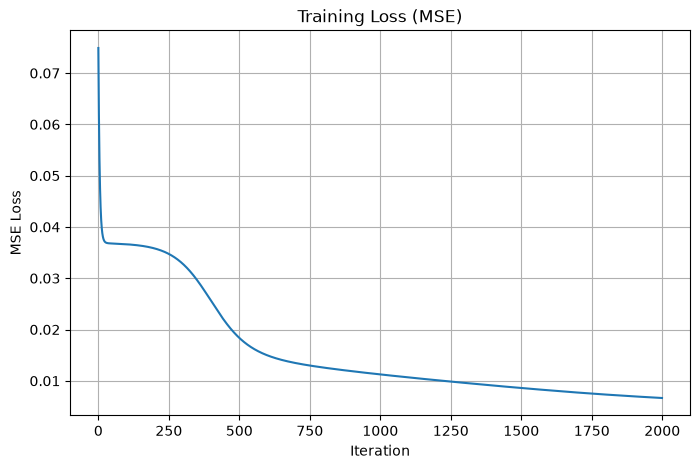

In [146]:
# Prepare data for the small NN: use train/test provided by files (no internal split)
# y_train exists from earlier cell
y_array = np.array(y_train).reshape(-1, 1)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_array)
if y_test is not None:
    y_test_array = np.array(y_test).reshape(-1, 1)
    y_test_scaled = scaler_y.transform(y_test_array)
else:
    y_test_scaled = None
# Transpose for our implementation: (n_x, m)
X_train_T = X_train_scaled.T
X_test_T = X_test_scaled.T
y_train_T = y_train_scaled.T
y_test_T = y_test_scaled.T if y_test_scaled is not None else None

# Train small 2-layer NN
np.random.seed(42)  # for reproducibility
W1_tr, b1_tr, W2_tr, b2_tr, losses = train_neural_network(X_train_T, y_train_T, n_h=10, epochs=2000, learning_rate=0.05, print_every=200)

# Plot training loss
plt.plot(losses, color='tab:blue')
plt.title('Training Loss (MSE)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

In [147]:
# Evaluate on test set
A2_test, _ = forward_propagation(X_test_T, W1_tr, b1_tr, W2_tr, b2_tr)
# inverse transform scaled predictions
y_pred_scaled = A2_test.T  # shape (m, 1)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
# If true test labels exist, compute RMSE, otherwise save predictions to CSV for submission
if y_test is not None:
    y_test_orig = scaler_y.inverse_transform(np.array(y_test).reshape(-1,1))
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    print(f'RMSE on test set: {rmse:.4f}')
else:
    # Include original ID column (if present) for Kaggle submission — keep alignment with rows kept after preprocessing
    if 'ID' in test_raw.columns:
        ids = test_raw.loc[test_final.index, 'ID'].values
    elif 'Id' in test_raw.columns:
        ids = test_raw.loc[test_final.index, 'Id'].values
    else:
        ids = test_final.index.values
    submission = pd.DataFrame({'Id': ids, 'Price': y_pred.flatten()})
    print('submission rows:', len(submission))
    submission.to_csv('submission.csv', index=False)
    print('Predictions saved to submission.csv')


submission rows: 171
Predictions saved to submission.csv
